In [1]:
import importlib
import logging
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

logging.basicConfig()
logging.getLogger().setLevel(logging.INFO)

from datetime import datetime
from portfolio_optimization import *
import numpy as np

# S&P and Dow Jones Tickers
sp_dj_asset_tickers = {
    "SPY": "U.S. Equities",                     # SPDR S&P 500 ETF Trust                     
    "SPDW": "International Equities",           # SPDR Portfolio Developed World ex-US ETF
    "SPEM": "Emerging Market Equities",         # SPDR Portfolio Emerging Markets ETF
    "RWX": "Real Estate",                       # SPDR Dow Jones International Real Estate ETF (RWX)
    "^SPGSCI": "Commodities",                     # Dow Jones Commodity Index
    "LQD": "Investment-Grade Bonds",            # S&P 500 Bond Index
    "SPHY": "High-Yield Bonds",                 # SPDR Portfolio High Yield Bond ETF
    "BWX": "International Sovereign Bonds"      # SPDR Bloomberg International Treasury Bond ETF
}


trading_days_in_year = 252
# Define the start and end dates for fetching the data
start_date = '1998-01-01'
end_date = datetime.today().strftime("%Y-%m-%d")

In [2]:
!pip install pandas yfinance matplotlib seaborn -q

In [3]:
tickers = dict(sp_dj_asset_tickers)

returns_df = download_tickers_returns(tickers=tickers, start_date="1998-12-23", cache_path="../data/historical-asset-classes-returns.csv")
returns_df.head()

,U.S. Equities,International Equities,Emerging Market Equities,Real Estate,Commodities,Investment-Grade Bonds,High-Yield Bonds,International Sovereign Bonds
Date,,,,,,,,
1998-12-24,-0.004311,0.0,0.0,0.0,0.000231,0.0,0.0,0.0
1998-12-28,-0.002548,0.0,0.0,0.0,0.005541,0.0,0.0,0.0
1998-12-29,0.015832,0.0,0.0,0.0,0.010102,0.0,0.0,0.0
1998-12-30,-0.008044,0.0,0.0,0.0,-0.002349,0.0,0.0,0.0
1998-12-31,0.000000,0.0,0.0,0.0,0.010253,0.0,0.0,0.0


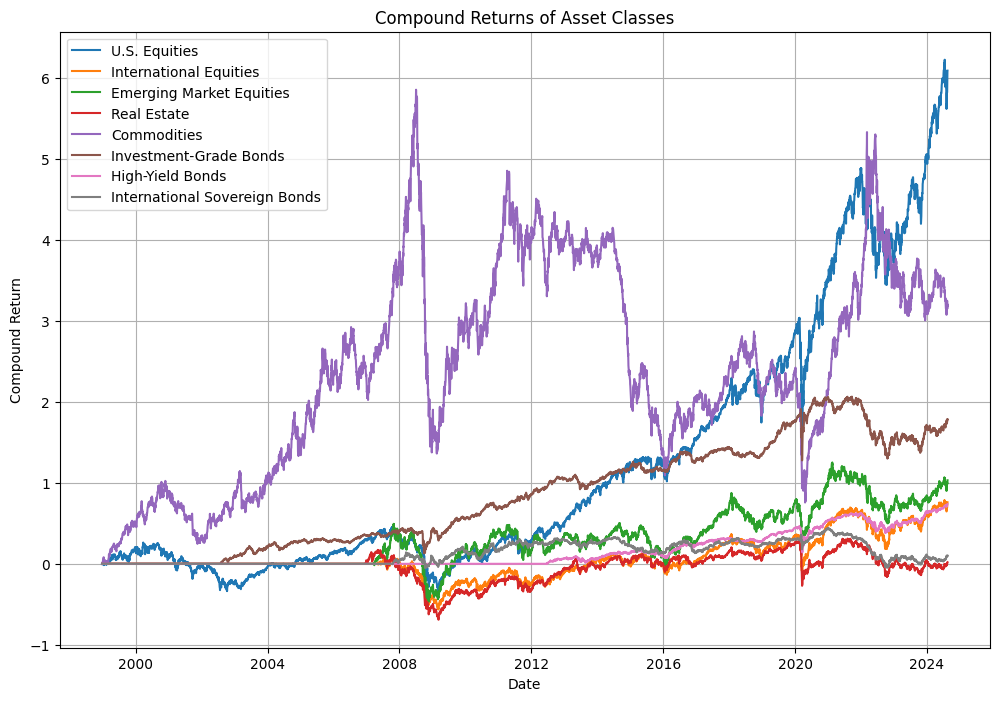

In [4]:
# Calculate compound returns
compound_returns = (1 + returns_df).cumprod() - 1

# Plot the compound returns
plt.figure(figsize=(12, 8))
for column in compound_returns.columns:
    plt.plot(compound_returns.index, compound_returns[column], label=column)

plt.title('Compound Returns of Asset Classes')
plt.ylabel('Compound Return')
plt.xlabel('Date')
plt.legend()
plt.grid(True)
plt.show()

differentiates between upside and downside volatility. The Sortino Ratio considers only downside volatility when assessing risk.

In [ ]:
import scipy
import numpy as np
def semi_variance(returns, threshold=0):
    downside_diff = np.minimum(0, returns - threshold)
    return np.mean(downside_diff**2)
def downside_deviation(returns, threshold=0):
    return np.sqrt(semi_variance(returns, threshold))
def sortino_ratio(expected_return, returns, risk_free_rate=0.01):
    downside_dev = downside_deviation(returns, threshold=risk_free_rate)
    return (expected_return - risk_free_rate) / downside_dev
def omega_ratio(returns, threshold=0):
    gains = np.sum(returns[returns > threshold] - threshold)
    losses = np.sum(threshold - returns[returns < threshold])
    return gains / losses
def portfolio_skewness(weights, returns):
    port_returns = np.dot(weights, returns)
    return scipy.stats.skew(port_returns)
def portfolio_kurtosis(weights, returns):
    port_returns = np.dot(weights, returns)
    return scipy.stats.kurtosis(port_returns)

def value_at_risk(returns, confidence_level=0.05):
    var = np.percentile(returns, 100 * confidence_level)
    return var
def cvar(returns, confidence_level=0.05):
    var = value_at_risk(returns=returns)
    return returns[returns <= var].mean()
def modified_var(returns, confidence_level=0.05):
    mean = np.mean(returns)
    std_dev = np.std(returns)
    skewness = scipy.stats.skew(returns)
    kurtosis = scipy.stats.kurtosis(returns)
    z_score = scipy.stats.norm.ppf(confidence_level)
    
    modified_z = (z_score + (1/6) * (z_score**2 - 1) * skewness + 
                  (1/24) * (z_score**3 - 3 * z_score) * kurtosis - 
                  (1/36) * (2 * z_score**3 - 5 * z_score) * skewness**2)
    
    return mean + modified_z * std_dev


/home/alan/Quantropy/src/portfolio_optimization.py:433: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  stored_weights_filled = stored_weights_shifted.ffill().fillna(0)


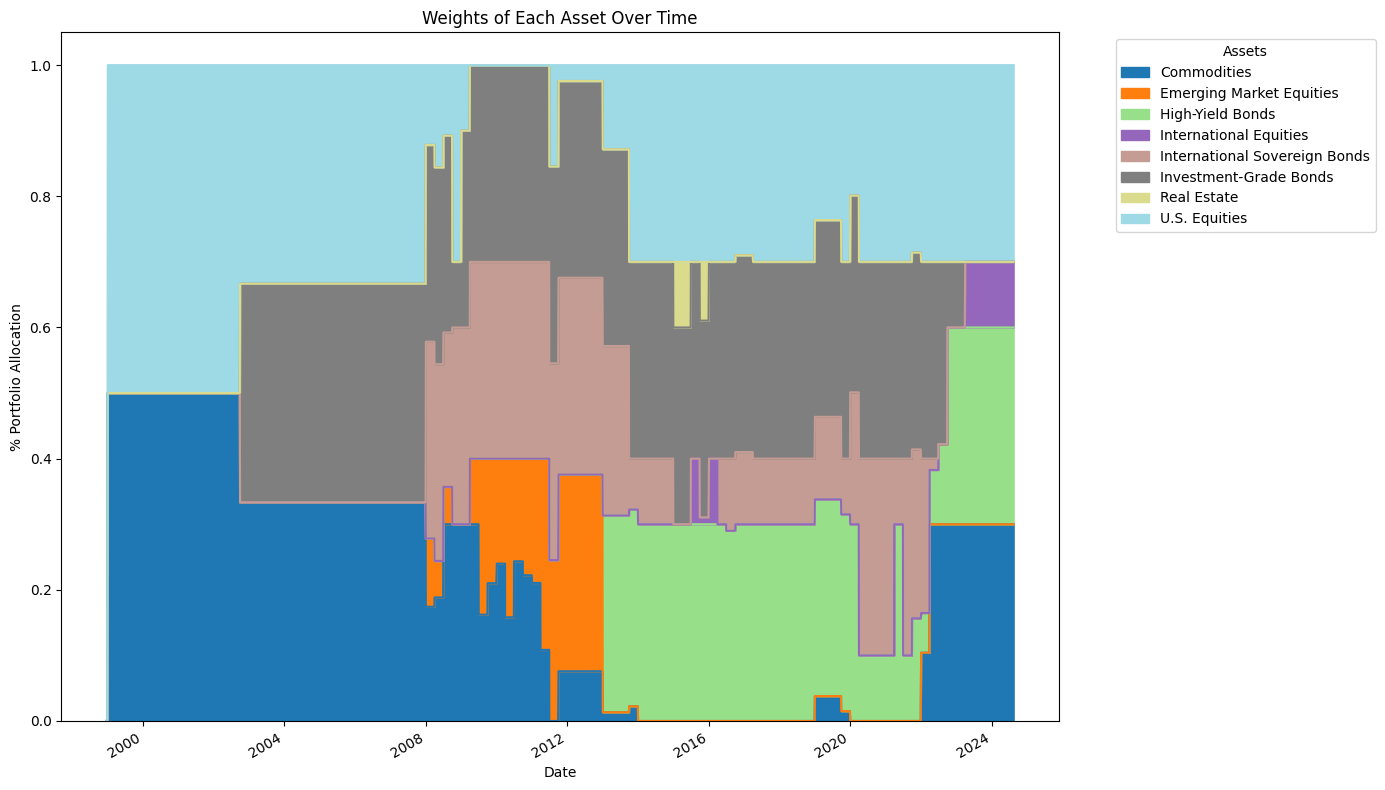

In [19]:
sharpe_portfolio_returns, sharpe_weights = portfolio_allocation(returns_df, frequency='daily', method='maxSharpe', max_exposure=0.3)
plot_weight_allocations(weights=sharpe_weights)

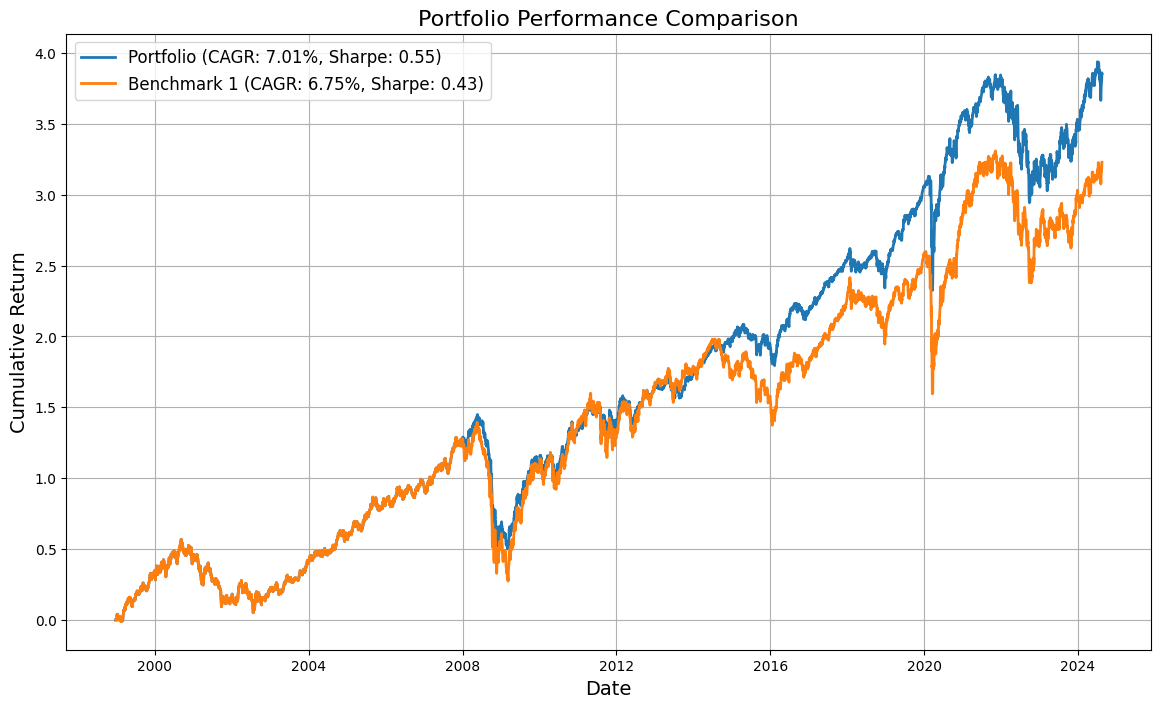

In [20]:
sharpe_returns_df = sharpe_portfolio_returns.to_frame(name="Max Sharpe Portfolio")
eq_returns_df = eq_portfolio_returns.to_frame(name="Equal Allocation Portfolio")
portf_and_bench_returns = sharpe_returns_df.join(eq_returns_df)

# Plot the performance
plot_portfolio_performance(portfolio_returns=portf_and_bench_returns["Max Sharpe Portfolio"],
                           benchmark_returns=portf_and_bench_returns["Equal Allocation Portfolio"])


Current Recommendation

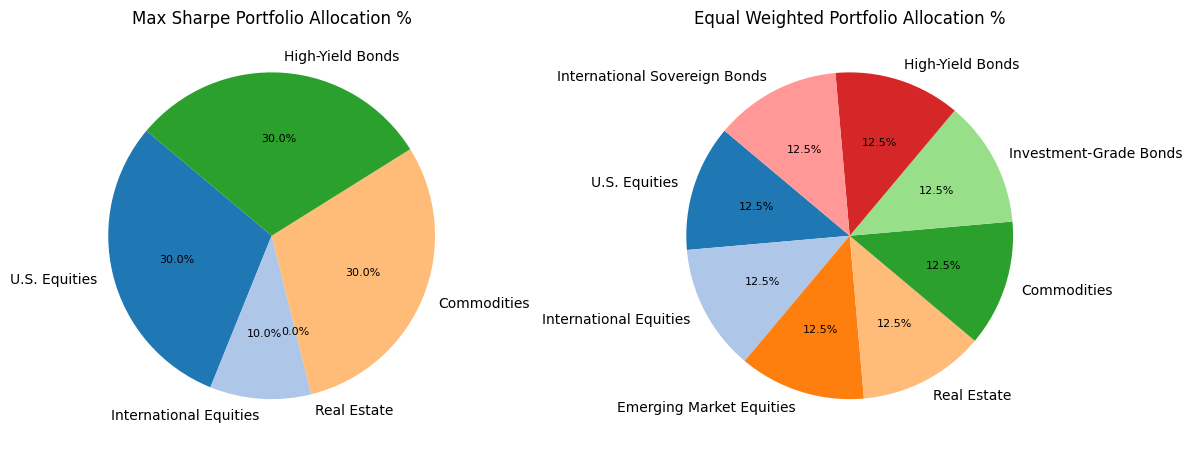

In [21]:
plot_piecharts(items=[sharpe_weights.iloc[-1], eq_weights.iloc[-1]], 
               titles=("Max Sharpe Portfolio Allocation %", "Equal Weighted Portfolio Allocation %"))

Our portfolio seemed to have given a better return, for a lower volatility, hence giving a higher Sharpe ratio.
Note: some abus de language
* Sharpe Ratio includes a risk-free rate. haven't mentioned here to keep it one concept at a time. better use "risk-adjusted return' or 'return per unit of risk'

In [22]:
portfolio_performance(portfolio_returns=sharpe_portfolio_returns, frequency="daily")

,inception,1Y,3Y,5Y,10Y
annualized_return,0.070065,0.115747,0.009592,0.054745,0.055433
annualized_volatility,0.109744,0.079081,0.105746,0.107162,0.085499
sharpe_ratio,0.547323,1.337197,-0.003859,0.417546,0.531393


In [26]:
portfolio_performance(portfolio_returns=eq_portfolio_returns, frequency="daily")

,inception,1Y,3Y,5Y,10Y
annualized_return,0.067465,0.118292,0.006444,0.060939,0.042865
annualized_volatility,0.133809,0.083024,0.109140,0.128202,0.108932
sharpe_ratio,0.429455,1.304344,-0.032582,0.397332,0.301706


Modern Portfolio Theory is fundamentally sound, in the way that it computes portfolio volatility and returns given individual assets. However, given non-normally distributed assets:

Mean returns isn't necessarily a good proxy to Expected Returns (CLT, Law of Large Numbers). 

Portfolio volatiltiy isn't necessarily a good proxy to "Risk", and computing it using a standard covariance matrix contributes to the problem.

Overall risk is based on correlations; however, they are not static, but change over time...

Highly sensitive; can concentrate a big % to one asset, and nothing to others.

Highly dependent on timeframe (lookback period)



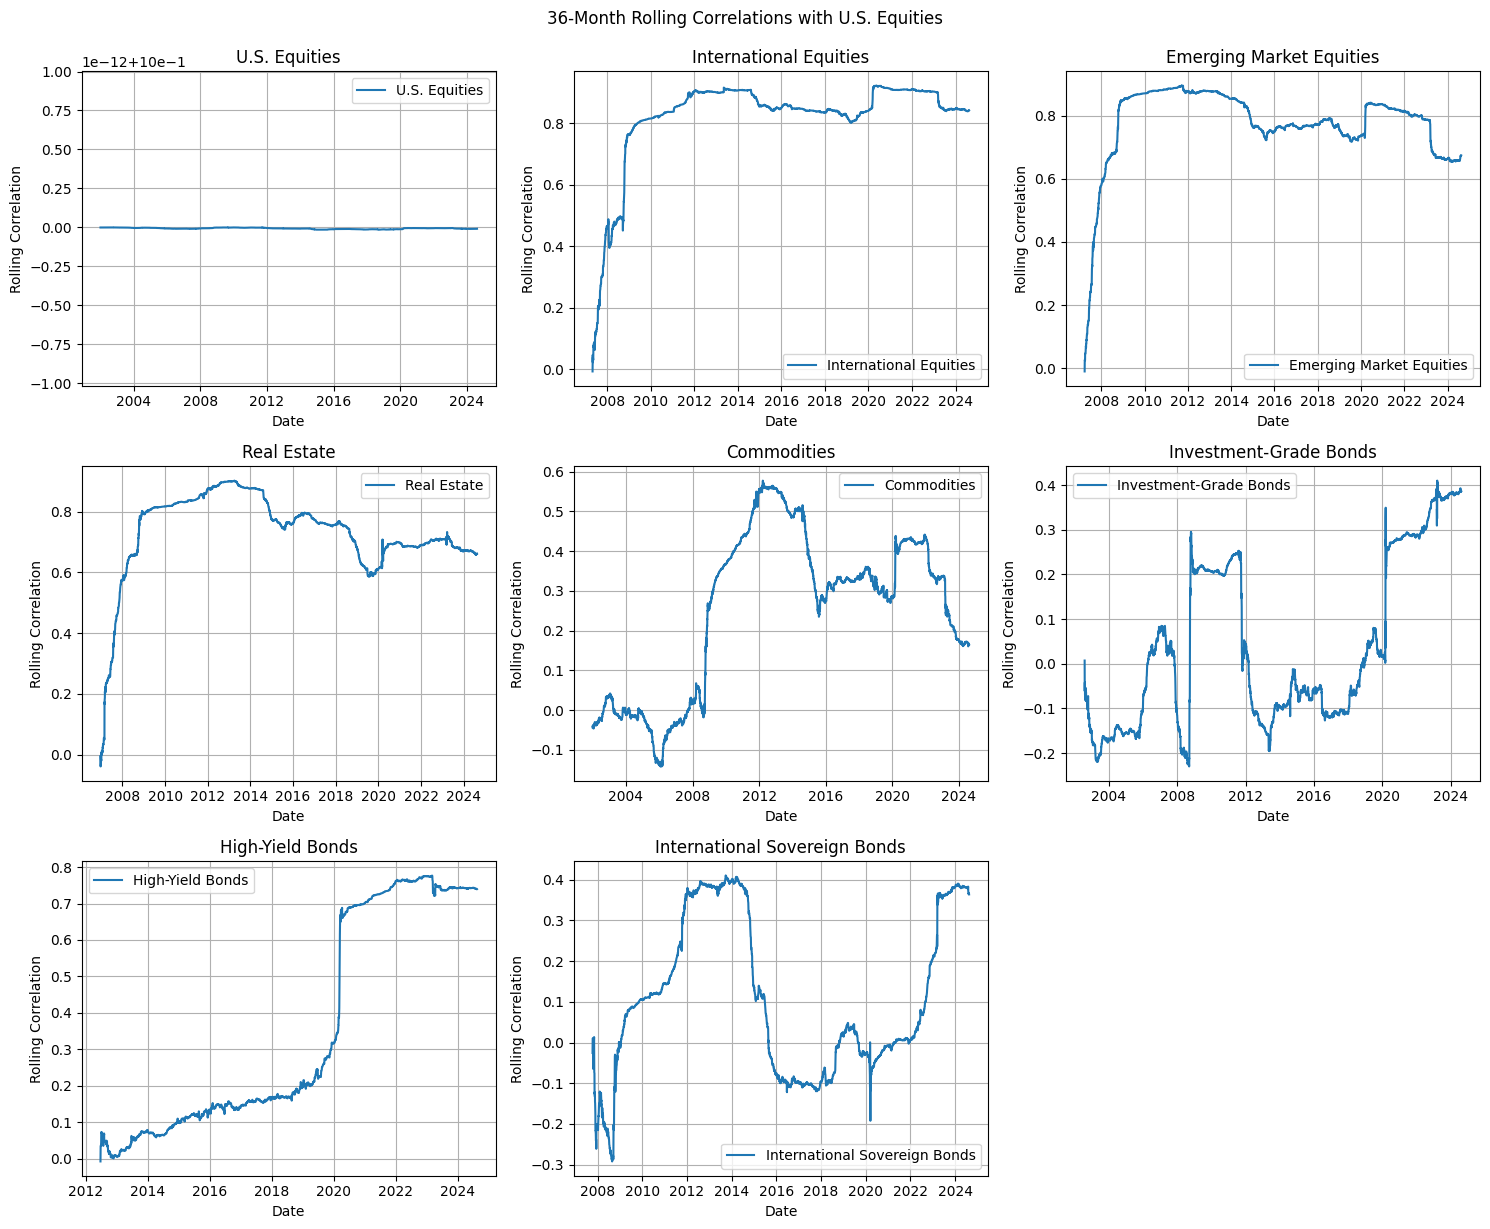

In [24]:
target_asset = 'U.S. Equities'  # Replace with your target asset class
comparison_assets = returns_df.columns  # Replace with your list of comparison asset classes
plot_rolling_correlations(returns_df, target_asset, comparison_assets, window_months=36)